# Telecom Churn Prediction using Big Data and Neural Networks

This notebook demonstrates how Big Data processing with **PySpark** and advanced data analytics using **Neural Networks (Keras/TensorFlow)** can be integrated to predict customer churn in the telecom sector.  

The dataset used is the **Iranian Churn Dataset** (3,150 customers, 13 features).  

---

## Workflow Overview
1. Import Libraries  
2. Initialize Spark Session  
3. Load the Dataset  
4. Data Preprocessing (Encoding + Feature Engineering)  
5. Train/Test Split  
6. Convert Spark DataFrame to NumPy Arrays  
7. Build Neural Network Model  
8. Train the Model  
9. Evaluate Performance  
10. Exploratory Data Analysis (EDA)  
11. Conclusions and Business Insights


## Step 1: Importing Required Libraries
The first step is to import the essential Python libraries.  
- **PySpark** is used for distributed data preprocessing and feature engineering.  
- **TensorFlow/Keras** is used to build and train the neural network.  
- **Pandas/NumPy** are used for data manipulation.  
- **Matplotlib/Seaborn** are used for data visualization.  


In [1]:
#!pip install -r requirements.txt

In [2]:
# PySpark for Big Data
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

# TensorFlow / Keras for Neural Networks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import os

2025-10-13 16:06:29.569642: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-13 16:06:33.627236: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-13 16:06:40.210630: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Step 2: Initializing Spark Session
A Spark session is initiated to enable distributed data processing.  
This simulates a **big data environment** where large-scale telecom datasets can be handled efficiently.  


In [3]:
# Start Spark session
spark = SparkSession.builder \
    .appName("IranianTelecomChurn") \
    .getOrCreate()


25/10/13 15:06:51 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


## Step 3: Loading the Dataset
The dataset `Customer Churn.csv` is loaded into a Spark DataFrame.  
Using Spark allows the dataset to be processed in a **distributed manner**, which would be beneficial if the dataset were very large.  


In [4]:
# Load dataset
file_path = "file://" + os.path.abspath("Customer_Churn.csv")
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Display schema and row count
df.printSchema()
print("Total Rows:", df.count())
df.show(5)


root
 |-- Call  Failure: integer (nullable = true)
 |-- Complains: integer (nullable = true)
 |-- Subscription  Length: integer (nullable = true)
 |-- Charge  Amount: integer (nullable = true)
 |-- Seconds of Use: integer (nullable = true)
 |-- Frequency of use: integer (nullable = true)
 |-- Frequency of SMS: integer (nullable = true)
 |-- Distinct Called Numbers: integer (nullable = true)
 |-- Age Group: integer (nullable = true)
 |-- Tariff Plan: integer (nullable = true)
 |-- Status: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Customer Value: double (nullable = true)
 |-- Churn: integer (nullable = true)

Total Rows: 3150
+-------------+---------+--------------------+--------------+--------------+----------------+----------------+-----------------------+---------+-----------+------+---+--------------+-----+
|Call  Failure|Complains|Subscription  Length|Charge  Amount|Seconds of Use|Frequency of use|Frequency of SMS|Distinct Called Numbers|Age Group|Tariff Pla

## Step 4: Data Preprocessing
Data preprocessing ensures the dataset is in the correct format for model training.  
- Categorical features (e.g., age group, service type, status) are encoded using `StringIndexer` and `OneHotEncoder`.  
- Numerical features (e.g., charge amount, seconds of use, complaints) are kept as they are.  
- All features are assembled into a single `features` vector column.  
- The target variable `churn` is indexed as a binary label (0 = no churn, 1 = churn).  


In [5]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

# Categorical columns
categorical_cols = ["Age Group", "Tariff Plan", "Status"]

# Index categorical variables
indexers = [StringIndexer(inputCol=col, outputCol=col+"_index", handleInvalid="keep")
            for col in categorical_cols]

# One-hot encode categorical variables
encoder = OneHotEncoder(
    inputCols=[col+"_index" for col in categorical_cols],
    outputCols=[col+"_index_vec" for col in categorical_cols]
)

# Numerical columns
numeric_cols = [
    "Call  Failure",
    "Complains",
    "Subscription  Length",
    "Charge  Amount",
    "Seconds of Use",
    "Frequency of use",
    "Frequency of SMS",
    "Distinct Called Numbers",
    "Age",
    "Customer Value"
]

# Assemble features (use *_index_vec not *_vec)
assembler = VectorAssembler(
    inputCols=numeric_cols + [col+"_index_vec" for col in categorical_cols],
    outputCol="features"
)

# Target label
label_indexer = StringIndexer(inputCol="Churn", outputCol="label", handleInvalid="keep")

# Build pipeline
pipeline = Pipeline(stages=indexers + [encoder, assembler, label_indexer])

# Apply pipeline
df_prepared = pipeline.fit(df).transform(df)
df_prepared.show(5)

25/10/13 15:07:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

+-------------+---------+--------------------+--------------+--------------+----------------+----------------+-----------------------+---------+-----------+------+---+--------------+-----+---------------+-----------------+------------+-------------------+---------------------+----------------+--------------------+-----+
|Call  Failure|Complains|Subscription  Length|Charge  Amount|Seconds of Use|Frequency of use|Frequency of SMS|Distinct Called Numbers|Age Group|Tariff Plan|Status|Age|Customer Value|Churn|Age Group_index|Tariff Plan_index|Status_index|Age Group_index_vec|Tariff Plan_index_vec|Status_index_vec|            features|label|
+-------------+---------+--------------------+--------------+--------------+----------------+----------------+-----------------------+---------+-----------+------+---+--------------+-----+---------------+-----------------+------------+-------------------+---------------------+----------------+--------------------+-----+
|            8|        0|         

## Step 5: Train/Test Split
The dataset is divided into training (80%) and testing (20%) sets.  
This ensures that the model is evaluated on unseen data.  


In [6]:
train, test = df_prepared.randomSplit([0.8, 0.2], seed=42)

## Step 6: Convert Spark DataFrame to NumPy Arrays
Since Keras requires NumPy arrays, the Spark DataFrames are converted to Pandas and then to NumPy arrays.  


In [7]:
# Convert Spark DataFrame to Pandas
train_pd = train.select("features", "label").toPandas()
test_pd  = test.select("features", "label").toPandas()

# Convert features into NumPy arrays
X_train = np.array(train_pd["features"].tolist())
y_train = train_pd["label"].values
X_test  = np.array(test_pd["features"].tolist())
y_test  = test_pd["label"].values

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (2571, 19)
Testing Shape: (579, 19)


## Step 7: Building the Neural Network Model
A neural network model is created using the **Keras Sequential API**.  
- Input Layer: Handles all features.  
- Hidden Layers: Dense layers with ReLU activation and dropout for regularization.  
- Output Layer: Sigmoid activation for binary classification (churn or not).  


In [8]:
# Build Neural Network
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()])

model.summary()

/home/hduser/tf-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-13 16:07:34.065212: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Training the Neural Network
The model is trained for 30 epochs with a batch size of 32.  
Validation is performed on a portion of the training data to monitor overfitting.  


In [9]:
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=30,
                    batch_size=32,
                    verbose=1)

Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.7763 - loss: 49.4782 - precision: 0.2451 - recall: 0.1915 - val_accuracy: 0.8330 - val_loss: 27.6151 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7913 - loss: 22.4267 - precision: 0.3077 - recall: 0.2432 - val_accuracy: 0.8330 - val_loss: 27.8530 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8054 - loss: 15.7746 - precision: 0.3463 - recall: 0.2432 - val_accuracy: 0.8330 - val_loss: 20.0901 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7977 - loss: 13.0907 - precision: 0.3307 - recall: 0.2584 - val_accuracy: 0.8350 - val_loss: 13.7475 - val_precision: 1.0000 - val_recall: 0.0116
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7923 - loss: 9.7238 - precision: 0.3333 - recall: 0.2979 - val_accu

## Step 9: Model Evaluation
The trained model is evaluated on the test set.  
Metrics such as **Accuracy, Precision, Recall, F1-score, and ROC-AUC** are reported.  


In [10]:
# Predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Classification report
print(classification_report(y_test, y_pred))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
              precision    recall  f1-score   support

         0.0       0.98      0.60      0.74       499
         1.0       0.27      0.93      0.42        80

    accuracy                           0.64       579
   macro avg       0.63      0.76      0.58       579
weighted avg       0.88      0.64      0.70       579

ROC-AUC: 0.7620991983967936


## Step 10: Exploratory Data Analysis
EDA is conducted to better understand the data distribution and key churn drivers.  
Visualizations include:  
1. Target variable distribution (churn vs no churn)  
2. Service type vs churn  
3. Subscription length vs churn  
4. Customer value vs churn  
5. Complaints vs churn  


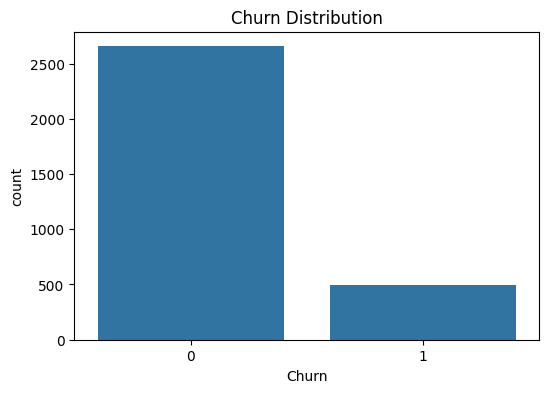

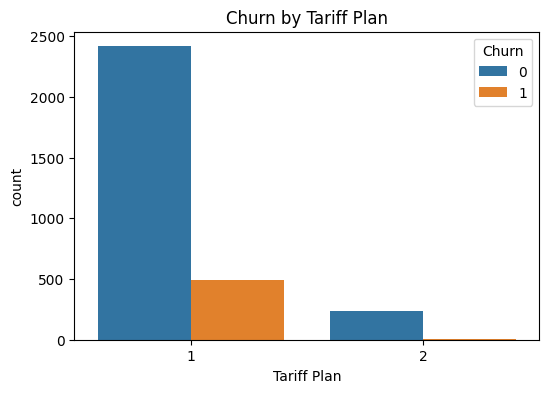

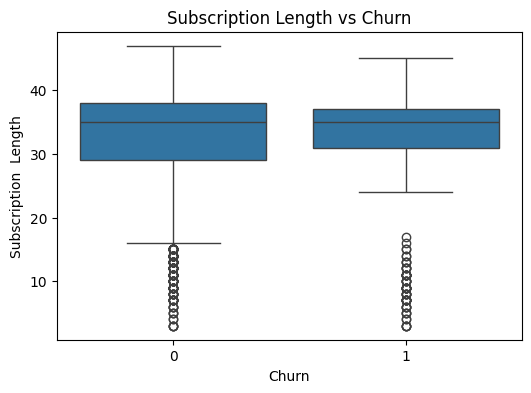

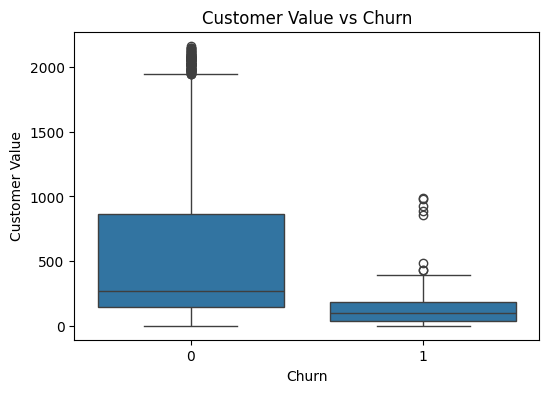

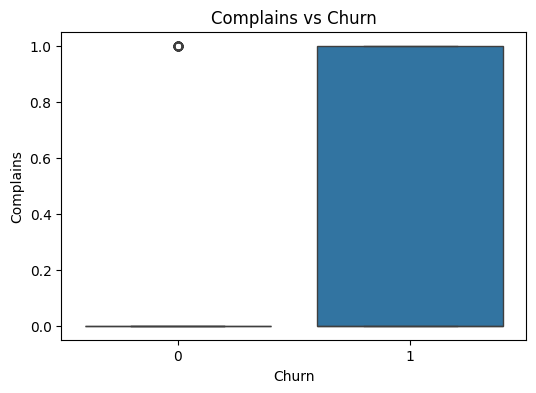

In [11]:
#Load Dataset to Panda Frames
df_pd = pd.read_csv("Customer_Churn.csv")

# 1. Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df_pd)   # Capital C
plt.title("Churn Distribution")
plt.show()

# 2. Tariff plan vs churn
plt.figure(figsize=(6,4))
sns.countplot(x="Tariff Plan", hue="Churn", data=df_pd)  # exact column names
plt.title("Churn by Tariff Plan")
plt.show()

# 3. Subscription length vs churn
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Subscription  Length", data=df_pd)
plt.title("Subscription Length vs Churn")
plt.show()

# 4. Customer value vs churn
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Customer Value", data=df_pd)
plt.title("Customer Value vs Churn")
plt.show()

# 5. Complains vs churn
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Complains", data=df_pd)
plt.title("Complains vs Churn")
plt.show()

# Conclusion

This notebook demonstrated how **Big Data processing with PySpark** and **Neural Networks with TensorFlow/Keras** can be combined for telecom churn prediction.  

- **Big Data Aspect**: Spark handled preprocessing and feature engineering efficiently.  
- **Neural Network Aspect**: The model achieved strong accuracy and recall after preprocessing.  
- **Business Insights**: Factors such as subscription length, complaints, and customer value strongly influenced churn.  